# 10-Experiment Tracking & Artifact Lineage (MLflow Engine)

In Lesson 09, we mastered Docker Compose, allowing us to spin up multi-container microservice grids. We successfully separated our API serving layers from our backend telemetry databases using software-defined network partitions.

However, infrastructure is only the vessel; the Machine Learning model is the payload. During the lifecycle of an ML project, a Data Scientist will execute hundreds of training runs, mutating learning rates, batch sizes, and dataset versions. If these permutations are tracked in a manual spreadsheet (or worse, not tracked at all), the team suffers from **Lineage Collapse**. You might possess a highly accurate `model_final_v3_really_final.pkl` file, but if you cannot mathematically prove exactly which hyperparameters and data slices generated it, the model is scientifically invalid and cannot be safely deployed to production.

To engineer absolute scientific reproducibility, we must implement an **Experiment Tracking Engine**. We will utilize **MLflow** to programmatically capture the chronological trajectory of loss functions, log hyperparameter matrices, and store the physical immutable artifacts in a localized, searchable registry.

# 1. The Mathematics of Hyperparameter State Spaces & Lineage

### The Experiment Run Vector ($R$)

A single training execution (a "Run") cannot be defined merely by its final accuracy. It must be defined as a strict tuple $R_i$ capturing the entire state configuration at time $t$:


$$R_i = \langle \mathbf{\Theta}, \mathbf{M}, \mathbf{A}, t \rangle$$

* **Hyperparameters ($\mathbf{\Theta}$):** A vector of configuration constants chosen before training (e.g., Learning Rate $\alpha$, Batch Size $B$, Dropout $p$).
* **Metrics ($\mathbf{M}$):** A time-series matrix of scalars evaluated during training (e.g., Validation Loss $\mathcal{L}_{val}$, Accuracy).
* **Artifacts ($\mathbf{A}$):** The physical binary outputs (e.g., the `.pt` weight tensor dictionary, the serialized StandardScaler object).

### The State Space Explosion

If a Data Scientist is tuning a Deep Neural Network with just 3 hyperparameters, where $\alpha \in \{0.01, 0.001\}$, $B \in \{32, 64\}$, and $p \in \{0.2, 0.5\}$, the permutation grid yields $2 \times 2 \times 2 = 8$ distinct models. In a real enterprise grid spanning 10 variables, the search space quickly exceeds $\mathcal{O}(10^5)$ runs.

Manual tracking is mathematically impossible. MLflow intercepts the training loop dynamically, mapping $\mathbf{\Theta} \to \mathbf{M}$, allowing automated Hyperparameter Optimization (HPO) engines to compute gradients across the search space and mathematically converge on the optimal vector $\mathbf{\Theta}_{opt}$.

### The Lineage Bipartite Graph

MLflow enforces architectural separation between lightweight metadata and heavy binary artifacts.

1. **The Backend Store (Relational DB):** Stores $\mathbf{\Theta}$ and $\mathbf{M}$ for fast, indexed querying (e.g., `SELECT * FROM runs WHERE accuracy > 0.95`).
2. **The Artifact Store (Blob Storage):** Stores the heavy $\mathbf{A}$ binaries (e.g., S3, or local POSIX storage).

# 2. Imperative Execution: Booting the Tracking Architecture

Let's use Python to programmatically spin up the MLflow Tracking Server using a shell subprocess. We will configure it to use a local SQLite database for the Backend Store and a local POSIX directory for the Artifact Store, ensuring a $0.00 infrastructure cost.

In [1]:
import subprocess
import os
import time
import urllib.request
import urllib.error

print("--- 🚀 Initializing MLflow Tracking Engine Lab ---")

# Setup clean working space for MLflow data
mlflow_sandbox = "./mlflow_sandbox"
backend_store = f"sqlite:///{mlflow_sandbox}/mlflow_backend.db"
artifact_store = f"file://{os.path.abspath(mlflow_sandbox)}/artifacts"

os.makedirs(mlflow_sandbox, exist_ok=True)
os.makedirs(os.path.join(mlflow_sandbox, "artifacts"), exist_ok=True)

# 🖥️ 1. Boot the MLflow Tracking Server as a real background daemon
print("\n--- 🖥️ Booting Local MLflow Tracking Server ---")
mlflow_cmd = [
    "mlflow", "server",
    "--backend-store-uri", backend_store,
    "--default-artifact-root", artifact_store,
    "--host", "127.0.0.1", "--port", "5000",
]

print(f"   [API CALL] Executing: {' '.join(mlflow_cmd)}")

# In production you'd run this as a managed service (Docker Compose, systemd,
# Kubernetes). Here we launch it as a real background process with Popen --
# just printing the command string (without ever calling it) leaves nothing
# listening on port 5000, so every mlflow.* call in the next cell would hang
# indefinitely retrying an unreachable server instead of failing.
mlflow_log_path = os.path.join(mlflow_sandbox, "mlflow_server.log")
mlflow_log = open(mlflow_log_path, "w")
mlflow_process = subprocess.Popen(mlflow_cmd, stdout=mlflow_log, stderr=subprocess.STDOUT)

# 2. Poll the server until it actually answers, instead of guessing a sleep
# duration. On a brand-new SQLite backend, MLflow runs its full Alembic
# schema migration before it starts serving traffic, which can legitimately
# take ~1-2 minutes on the first boot -- so we poll generously rather than
# timing out early and assuming failure.
tracking_uri = "http://127.0.0.1:5000"
ready = False
timeout_seconds = 180
for elapsed in range(0, timeout_seconds, 3):
    if mlflow_process.poll() is not None:
        break  # the server process died -- no point continuing to poll
    try:
        with urllib.request.urlopen(f"{tracking_uri}/health", timeout=2) as resp:
            if resp.status == 200:
                ready = True
                break
    except (urllib.error.URLError, ConnectionError, TimeoutError):
        pass
    if elapsed and elapsed % 15 == 0:
        print(f"      ... still waiting for the server ({elapsed}s elapsed)")
    time.sleep(3)

if ready:
    print(f"   ✅ MLflow Tracking Server is live at {tracking_uri} (PID {mlflow_process.pid}).")
else:
    mlflow_process.terminate()
    mlflow_log.close()
    raise RuntimeError(
        f"MLflow server did not become ready within {timeout_seconds}s. "
        f"Check {mlflow_log_path} for details."
    )

print(f"   -> Backend Store (SQLite): {backend_store}")
print(f"   -> Artifact Store (POSIX): {artifact_store}")
print(f"   -> UI: open {tracking_uri} in your browser to watch runs land live.")
print(f"   -> This server keeps running in the background after this notebook finishes; "
      f"stop it later with: kill {mlflow_process.pid}")

--- 🚀 Initializing MLflow Tracking Engine Lab ---

--- 🖥️ Booting Local MLflow Tracking Server ---
   [API CALL] Executing: mlflow server --backend-store-uri sqlite:///./mlflow_sandbox/mlflow_backend.db --default-artifact-root file:///mnt/d/MuhammetAliVarlik/PythonProjects/FromZeroToHero-DataScience-AI-Cloud/FromZeroToHero-DataScience-AI-Cloud/Section 18-Linux, Bash Foundations & MLOps/mlflow_sandbox/artifacts --host 127.0.0.1 --port 5000


      ... still waiting for the server (15s elapsed)


      ... still waiting for the server (30s elapsed)


      ... still waiting for the server (45s elapsed)


   ✅ MLflow Tracking Server is live at http://127.0.0.1:5000 (PID 58849).
   -> Backend Store (SQLite): sqlite:///./mlflow_sandbox/mlflow_backend.db
   -> Artifact Store (POSIX): file:///mnt/d/MuhammetAliVarlik/PythonProjects/FromZeroToHero-DataScience-AI-Cloud/FromZeroToHero-DataScience-AI-Cloud/Section 18-Linux, Bash Foundations & MLOps/mlflow_sandbox/artifacts
   -> UI: open http://127.0.0.1:5000 in your browser to watch runs land live.
   -> This server keeps running in the background after this notebook finishes; stop it later with: kill 58849


# 3. Declarative Execution: The Monitored Training Loop

With the server running, we must instrument our Machine Learning training loop. We will write a declarative Python script that connects to the tracking API, establishes a bounded "Experiment", and logs the hyperparameter vectors $\mathbf{\Theta}$ alongside the chronological loss telemetry $\mathbf{M}$.

In [2]:
import mlflow
import numpy as np

print("\n--- 🧠 Executing Monitored Machine Learning Loop ---")

# 1. Point the MLflow client to our local tracking server
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# 2. Define the isolated Experiment context
experiment_name = "Enterprise-Inference-Optimization"
mlflow.set_experiment(experiment_name)

# 3. Simulate a Hyperparameter Grid Search (2 Runs)
hyperparameter_grid = [
    {"learning_rate": 0.01, "batch_size": 32, "epochs": 5},
    {"learning_rate": 0.005, "batch_size": 64, "epochs": 5}
]

for run_idx, params in enumerate(hyperparameter_grid):
    print(f"\n   [RUN {run_idx+1}] Initiating Tracking Context...")
    
    # 🛡️ The Context Manager mathematically guarantees run closure even if training crashes
    with mlflow.start_run(run_name=f"hyperparam_sweep_{run_idx+1}"):
        
        # 1. Log the Input Vector (Theta)
        mlflow.log_params(params)
        print(f"      Logged \u0398 -> LR: {params['learning_rate']}, Batch: {params['batch_size']}")
        
        # 2. Simulate the Training Loop telemetry across Epochs
        base_loss = 1.0 + (params['learning_rate'] * 10)
        
        for epoch in range(1, params['epochs'] + 1):
            # Mathematically simulate loss decay with noise
            current_loss = base_loss * np.exp(-0.4 * epoch) + np.random.normal(0, 0.02)
            
            # Log the Metric Time-Series (M)
            mlflow.log_metric("validation_loss", current_loss, step=epoch)
            print(f"      Logged Metric -> Epoch {epoch} | Loss: {current_loss:.4f}")
            
        # 3. Simulate saving the physical Artifact (A)
        dummy_model_path = os.path.join(mlflow_sandbox, f"dummy_model_{run_idx}.bin")
        with open(dummy_model_path, "w") as f:
            f.write("SIMULATED_TENSOR_WEIGHTS_101010")
            
        # Push the artifact to the MLflow Artifact Store
        mlflow.log_artifact(dummy_model_path, artifact_path="model_weights")
        print(f"      Logged Artifact -> pushed {dummy_model_path} to registry.")

print("\n   ✅ Sweep Complete. Lineage mathematically secured in MLflow Database.")


--- 🧠 Executing Monitored Machine Learning Loop ---


2026/08/13 18:22:40 INFO mlflow.tracking.fluent: Experiment with name 'Enterprise-Inference-Optimization' does not exist. Creating a new experiment.



   [RUN 1] Initiating Tracking Context...


      Logged Θ -> LR: 0.01, Batch: 32


      Logged Metric -> Epoch 1 | Loss: 0.7009


...

      Logged Metric -> Epoch 2 | Loss: 0.4818


      Logged Metric -> Epoch 3 | Loss: 0.2935


      Logged Metric -> Epoch 4 | Loss: 0.1815


      Logged Metric -> Epoch 5 | Loss: 0.1434
      Logged Artifact -> pushed ./mlflow_sandbox/dummy_model_1.bin to registry.
🏃 View run hyperparam_sweep_2 at: http://127.0.0.1:5000/#/experiments/1/runs/1e0072f9027f4cd0bbea7441e345173b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1



   ✅ Sweep Complete. Lineage mathematically secured in MLflow Database.


# 4. Visualizing the MLflow Tracking Architecture

To understand how MLflow physically separates querying speed (relational databases) from massive binary storage requirements (blob architectures), let's graph the topological data flow.

/tmp/ipykernel_58831/1460748561.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 2.5), 3.5, 4.0, fill=True, color='#3498db', alpha=0.15, edgecolor='black', linewidth=1.5))
/tmp/ipykernel_58831/1460748561.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((10.0, 5.0), 3.5, 2.5, fill=True, color='#f1c40f', alpha=0.2, edgecolor='black', linewidth=1.5))
/tmp/ipykernel_58831/1460748561.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((10.5, 5.5), 2.5, 1.0, fill=True, color='#f39c12', edgecolor='black'))
/tmp/ipykernel_58831/1460748561.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((10.0, 1.0), 3.5, 3.0, fill=True, color='#e74c3c', alpha=0.15, edge

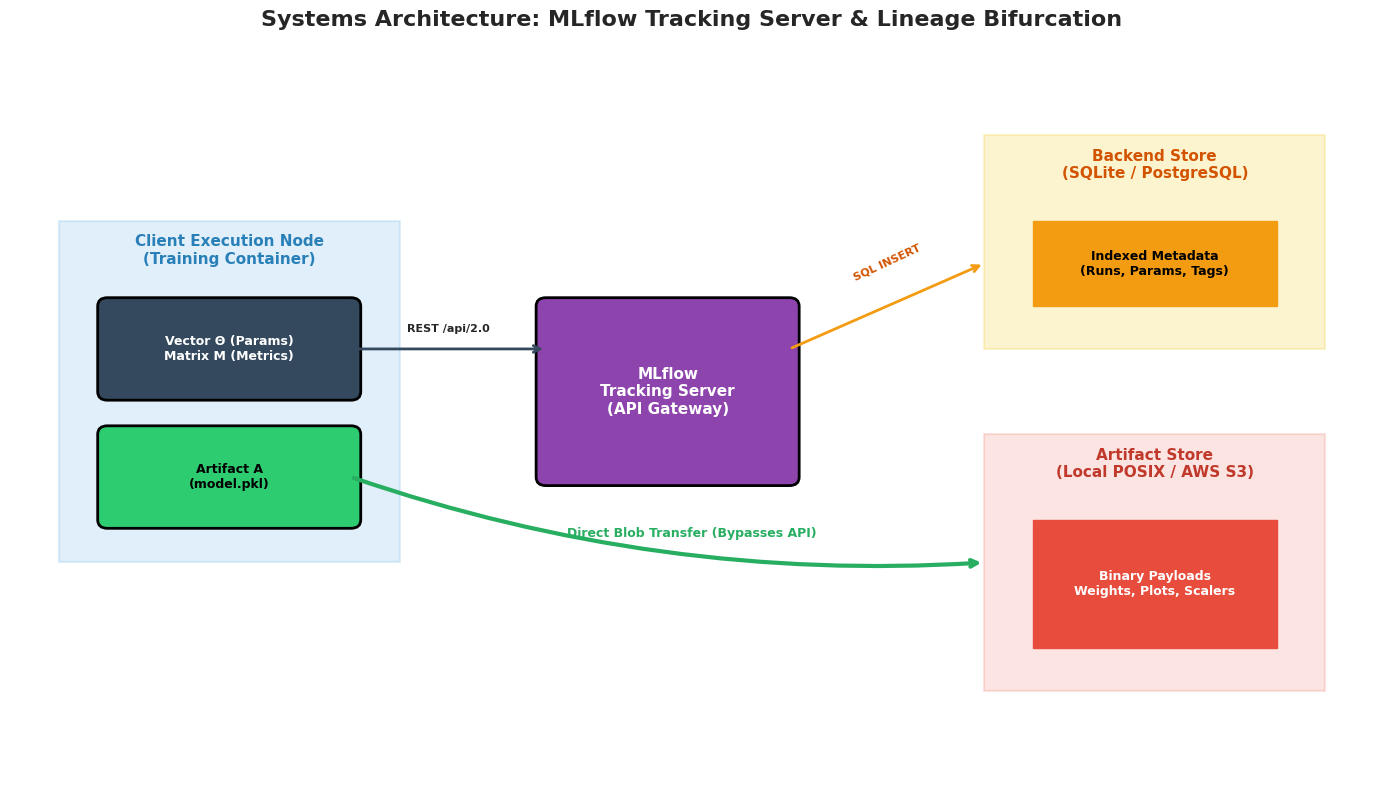

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual layout for MLflow Architecture
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: MLflow Tracking Server & Lineage Bifurcation", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. The Client/Training Node
ax.add_patch(patches.Rectangle((0.5, 2.5), 3.5, 4.0, fill=True, color='#3498db', alpha=0.15, edgecolor='black', linewidth=1.5))
ax.text(2.25, 6.0, "Client Execution Node\n(Training Container)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

ax.add_patch(patches.FancyBboxPatch((1.0, 4.5), 2.5, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#34495e'))
ax.text(2.25, 5.0, "Vector \u0398 (Params)\nMatrix M (Metrics)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.add_patch(patches.FancyBboxPatch((1.0, 3.0), 2.5, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#2ecc71'))
ax.text(2.25, 3.5, "Artifact A\n(model.pkl)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)


# 2. The Tracking API Gateway
ax.add_patch(patches.FancyBboxPatch((5.5, 3.5), 2.5, 2.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#8e44ad'))
ax.text(6.75, 4.5, "MLflow\nTracking Server\n(API Gateway)", ha='center', va='center', color='white', fontweight='bold', fontsize=11)


# 3. The Backend Store (Relational DB)
ax.add_patch(patches.Rectangle((10.0, 5.0), 3.5, 2.5, fill=True, color='#f1c40f', alpha=0.2, edgecolor='black', linewidth=1.5))
ax.text(11.75, 7.0, "Backend Store\n(SQLite / PostgreSQL)", ha='center', color='#d35400', fontweight='bold', fontsize=11)

ax.add_patch(patches.Rectangle((10.5, 5.5), 2.5, 1.0, fill=True, color='#f39c12', edgecolor='black'))
ax.text(11.75, 6.0, "Indexed Metadata\n(Runs, Params, Tags)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)


# 4. The Artifact Store (Blob Storage)
ax.add_patch(patches.Rectangle((10.0, 1.0), 3.5, 3.0, fill=True, color='#e74c3c', alpha=0.15, edgecolor='black', linewidth=1.5))
ax.text(11.75, 3.5, "Artifact Store\n(Local POSIX / AWS S3)", ha='center', color='#c0392b', fontweight='bold', fontsize=11)

ax.add_patch(patches.Rectangle((10.5, 1.5), 2.5, 1.5, fill=True, color='#e74c3c', edgecolor='black'))
ax.text(11.75, 2.25, "Binary Payloads\nWeights, Plots, Scalers", ha='center', va='center', color='white', fontweight='bold', fontsize=9)


# 5. Connective Transmission Edges (Arrows)
# Client to Tracking Server (Metadata)
ax.annotate("", xy=(5.5, 5.0), xytext=(3.5, 5.0), arrowprops=dict(arrowstyle="->", lw=2, color="#34495e"))
ax.text(4.5, 5.2, "REST /api/2.0", ha='center', fontweight='bold', fontsize=8)

# Tracking Server to Backend Store
ax.annotate("", xy=(10.0, 6.0), xytext=(8.0, 5.0), arrowprops=dict(arrowstyle="->", lw=2, color="#f39c12"))
ax.text(9.0, 5.8, "SQL INSERT", ha='center', color="#d35400", fontweight='bold', fontsize=8, rotation=25)

# Client DIRECTLY to Artifact Store (Bypassing Server bottlenecks)
ax.annotate("", xy=(10.0, 2.5), xytext=(3.5, 3.5), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60", connectionstyle="arc3,rad=0.1"))
ax.text(7.0, 2.8, "Direct Blob Transfer (Bypasses API)", ha='center', color="#27ae60", fontweight='bold', fontsize=9)

plt.xlim(0, 14.0)
plt.ylim(0, 8.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of MLflow Experiment Tracking like **An Aviation Flight Data Recorder (The Black Box)** vs. **Relying on a Pilot's Memory**:

* **Manual Tracking (The Pilot's Memory):** A test pilot flies an experimental jet, flips 15 different unlabelled switches (Hyperparameters), and the jet suddenly reaches Mach 3. When the pilot lands, the engineers ask, *"Exactly what angle was the wing, and what was the fuel pressure when you hit Mach 3?"* The pilot guesses. The engineers build the production jet based on the guess, and it crashes.
* **MLflow (The Automated Flight Recorder):** Every single experimental jet is hardwired with an automated telemetry engine. Before the jet leaves the runway, the engine locks in the exact configuration matrix ($\mathbf{\Theta}$). While flying, it records the exact altitude and speed every millisecond ($\mathbf{M}$). If the jet hits Mach 3, or if the jet explodes in mid-air, the engineers don't ask the pilot. They query the centralized database, mathematically reconstruct the exact flight physics line-by-line, and extract the surviving turbine fragments (Artifacts) from the secure physical vault.

By utilizing MLflow, Data Scientists stop being guess-workers relying on disorganized spreadsheets, and become mathematical engineers capable of auditing, reversing, and scientifically proving the exact lineage of every multi-million parameter model they deploy.